# Understanding Regression Models (Linear Regression & Polynomial Regression)

## Importation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Reading the dataset

In [2]:

train = pd.read_csv("Train.csv")
test  = pd.read_csv("Test.csv")
print("Train shape:", train.shape)
print("Test shape :", test.shape)
train.head()

Train shape: (8128, 8)
Test shape : (4340, 8)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner


## Prepare the features
Select the numeric columns (year, km_driven) and one-hot encode the categorical
columns (fuel, seller_type, transmission, owner) into 0/1 columns, dropping one
level per category to avoid redundancy. Also split out the target, `selling_price`.

In [3]:
TARGET  = "selling_price"
NUMERIC = ["year", "km_driven"]
CATEG   = ["fuel", "seller_type", "transmission", "owner"]

# categorical levels fixed from TRAIN (drop first level of each)
cat_levels = {c: sorted(train[c].unique())[1:] for c in CATEG}
feat_names = NUMERIC + [f"{c}={lvl}" for c in CATEG for lvl in cat_levels[c]]

def build_design(df):
    num  = df[NUMERIC].astype(float).to_numpy()
    cols = [(df[c] == lvl).astype(float).to_numpy()
            for c in CATEG for lvl in cat_levels[c]]
    return num, np.column_stack(cols)

num_tr, cat_tr = build_design(train)
num_te, cat_te = build_design(test)
y_tr = train[TARGET].astype(float).to_numpy()
y_te = test[TARGET].astype(float).to_numpy()
print(f"{len(feat_names)} features:", feat_names)

12 features: ['year', 'km_driven', 'fuel=Diesel', 'fuel=LPG', 'fuel=Petrol', 'seller_type=Individual', 'seller_type=Trustmark Dealer', 'transmission=Manual', 'owner=Fourth & Above Owner', 'owner=Second Owner', 'owner=Test Drive Car', 'owner=Third Owner']


## Standardize and set up helpers
Combine the features into one matrix and standardize each column (mean 0, std 1)
using training statistics. Standardize the target too, add a bias/intercept column,
and define the `metrics` (MSE, RMSE, MAE) and `predict_price` helper functions.

In [4]:
X_tr_raw = np.column_stack([num_tr, cat_tr])
X_te_raw = np.column_stack([num_te, cat_te])

mu_X, sd_X = X_tr_raw.mean(0), X_tr_raw.std(0); sd_X[sd_X == 0] = 1.0
X_tr = (X_tr_raw - mu_X) / sd_X
X_te = (X_te_raw - mu_X) / sd_X

mu_y, sd_y = y_tr.mean(), y_tr.std()
y_tr_s = (y_tr - mu_y) / sd_y

add_bias = lambda X: np.column_stack([np.ones(len(X)), X])
Xb_tr, Xb_te = add_bias(X_tr), add_bias(X_te)

def metrics(y_true, y_pred):
    r = y_true - y_pred
    mse = float(np.mean(r**2))
    return {"MSE": mse, "RMSE": float(np.sqrt(mse)),
            "MAE": float(np.mean(np.abs(r))), "SSE": float(np.sum(r**2)),
            "mean_residual": float(np.mean(r))}

predict_price = lambda X, b: (X @ b) * sd_y + mu_y
print("X_tr:", Xb_tr.shape, " X_te:", Xb_te.shape)

X_tr: (8128, 13)  X_te: (4340, 13)


## Linear Regression

### Linear Regression — Normal Equation
Fit the model in closed form with β = (XᵀX)⁻¹Xᵀy and report its test-set errors.

In [5]:
def normal_equation(X, y):
    return np.linalg.pinv(X.T @ X) @ X.T @ y

beta_ne = normal_equation(Xb_tr, y_tr_s)
pred_ne = predict_price(Xb_te, beta_ne)
m_ne = metrics(y_te, pred_ne)
print("Normal-Equation metrics (test set):")
for k, v in m_ne.items(): print(f"  {k:13s}: {v:,.4f}")

Normal-Equation metrics (test set):
  MSE          : 253,457,173,432.1368
  RMSE         : 503,445.3033
  MAE          : 312,861.5399
  SSE          : 1,100,004,132,695,473.7500
  mean_residual: -103,819.1798


### Linear Regression — Gradient Descent
Fit the same model iteratively by repeatedly stepping down the error gradient,
then report its test-set errors and confirm it matches the Normal Equation.

In [6]:
def gradient_descent(X, y, lr=0.1, epochs=8000):
    n, d = X.shape
    beta = np.zeros(d)
    hist = []
    for _ in range(epochs):
        err  = X @ beta - y
        beta -= lr * (X.T @ err) / n
        hist.append((err**2).mean())
    return beta, hist

beta_gd, cost_hist = gradient_descent(Xb_tr, y_tr_s, lr=0.1, epochs=8000)
pred_gd = predict_price(Xb_te, beta_gd)
m_gd = metrics(y_te, pred_gd)
print(f"GD converged: cost {cost_hist[0]:.4f} -> {cost_hist[-1]:.4f} over {len(cost_hist)} epochs")
print("Gradient-Descent metrics (test set):")
for k, v in m_gd.items(): print(f"  {k:13s}: {v:,.4f}")
print(f"\n||beta_NE - beta_GD|| = {np.linalg.norm(beta_ne - beta_gd):.3e}")

GD converged: cost 1.0000 -> 0.4968 over 8000 epochs
Gradient-Descent metrics (test set):
  MSE          : 253,457,176,875.7270
  RMSE         : 503,445.3067
  MAE          : 312,861.5409
  SSE          : 1,100,004,147,640,655.0000
  mean_residual: -103,819.1876

||beta_NE - beta_GD|| = 2.017e-06


### Gradient descent convergence
Plot the training error over epochs to show it settling at the optimum.

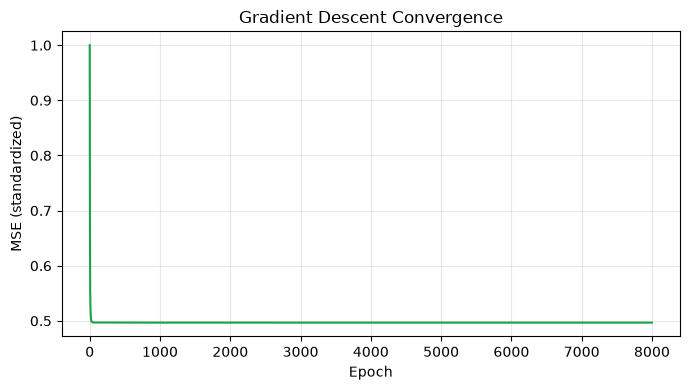

In [7]:
plt.figure(figsize=(7,4))
plt.plot(cost_hist, color="#16a34a")
plt.xlabel("Epoch"); plt.ylabel("MSE (standardized)")
plt.title("Gradient Descent Convergence"); plt.grid(alpha=.3)
plt.tight_layout(); plt.savefig("gd_convergence.png", dpi=110); plt.show()

### Standardized coefficients
Show the β coefficient for each feature from both methods side by side.

In [8]:
coef = pd.DataFrame({"feature": feat_names,
                     "beta_NormalEq": beta_ne[1:],
                     "beta_GradDesc": beta_gd[1:]})
coef

,feature,beta_NormalEq,beta_GradDesc
0,year,0.220906,0.220906
1,km_driven,-0.061525,-0.061525
2,fuel=Diesel,0.202688,0.202687
3,fuel=LPG,0.009707,0.009707
4,fuel=Petrol,-0.010373,-0.010375
5,seller_type=Individual,-0.173366,-0.173366
6,seller_type=Trustmark Dealer,-0.101287,-0.101287
7,transmission=Manual,-0.471570,-0.471570
8,owner=Fourth & Above Owner,0.004613,0.004613
9,owner=Second Owner,-0.026306,-0.026306


### Compare the two linear models
Put both methods' error metrics in one table for comparison.

In [9]:
cmp = pd.DataFrame({"Normal Equation": m_ne, "Gradient Descent": m_gd}).T
cmp[["MSE","RMSE","MAE","SSE","mean_residual"]]

,MSE,RMSE,MAE,SSE,mean_residual
Normal Equation,2.534572e+11,503445.303317,312861.539862,1.100004e+15,-103819.179765
Gradient Descent,2.534572e+11,503445.306737,312861.540931,1.100004e+15,-103819.187607


## Plynomial Regression

### Polynomial Regression (degrees 1–10)
Expand the numeric features to higher powers, fit a model at each degree, and
record the test RMSE to find where accuracy is best.

In [10]:
z_tr = (num_tr - num_tr.mean(0)) / num_tr.std(0)
z_te = (num_te - num_tr.mean(0)) / num_tr.std(0)

def poly_design(z, cat, d):
    return np.column_stack([z**p for p in range(1, d+1)] + [cat])

poly_rows = []
for d in range(1, 11):
    Ptr, Pte = poly_design(z_tr, cat_tr, d), poly_design(z_te, cat_te, d)
    m, s = Ptr.mean(0), Ptr.std(0); s[s == 0] = 1.0
    Ptr, Pte = (Ptr - m)/s, (Pte - m)/s
    beta = normal_equation(add_bias(Ptr), y_tr_s)
    pred = predict_price(add_bias(Pte), beta)
    mm = metrics(y_te, pred)
    poly_rows.append({"degree": d, "RMSE": mm["RMSE"], "MSE": mm["MSE"], "MAE": mm["MAE"]})

poly_df = pd.DataFrame(poly_rows)
best_deg = int(poly_df.loc[poly_df.RMSE.idxmin(), "degree"])
print("Optimal degree:", best_deg)
poly_df

Optimal degree: 3


,degree,RMSE,MSE,MAE
0,1,503445.303317,2.534572e+11,312861.539862
1,2,492898.185648,2.429486e+11,304656.690166
2,3,492037.669326,2.421011e+11,302339.389433
3,4,494645.770092,2.446744e+11,304913.114505
4,5,495199.088177,2.452221e+11,306043.143628
5,6,495754.928319,2.457729e+11,306330.398167
6,7,502692.828417,2.527001e+11,307660.532299
7,8,723117.283366,5.228986e+11,314642.391172
8,9,763791.473093,5.833774e+11,316077.501650
9,10,816618.769629,6.668662e+11,316678.338990


### Degree vs RMSE
Plot RMSE against polynomial degree and mark the lowest-error (optimal) degree.

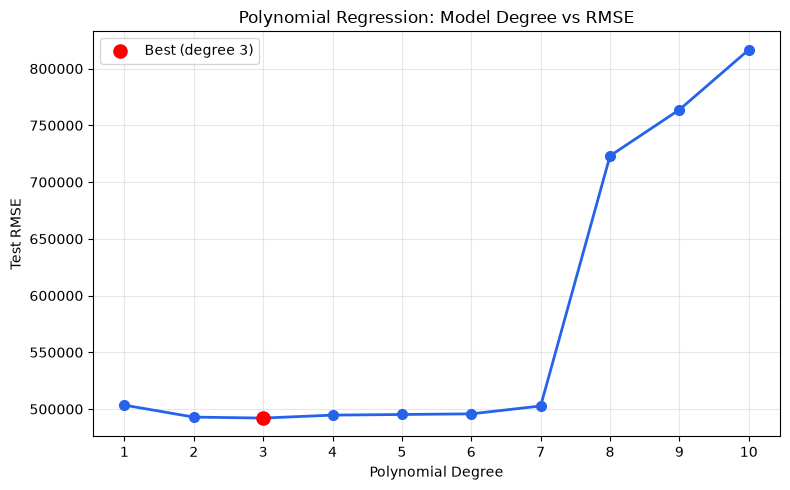

In [11]:
best = poly_df.loc[poly_df.RMSE.idxmin()]
plt.figure(figsize=(8,5))
plt.plot(poly_df.degree, poly_df.RMSE, "o-", color="#2563eb", lw=2, ms=7)
plt.scatter([best.degree], [best.RMSE], color="red", s=90, zorder=5,
            label=f"Best (degree {int(best.degree)})")
plt.xlabel("Polynomial Degree"); plt.ylabel("Test RMSE")
plt.title("Polynomial Regression: Model Degree vs RMSE")
plt.xticks(range(1,11)); plt.grid(alpha=.3); plt.legend()
plt.tight_layout(); plt.savefig("degree_vs_rmse.png", dpi=130); plt.show()